# Notebook 5 — Clustering (K-Means + CAH)


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../health_lifestyle_dataset.csv')
df['gender_enc'] = (df['gender'] == 'Male').astype(int)
df['hypertension'] = ((df['systolic_bp'] >= 140) | (df['diastolic_bp'] >= 90)).astype(int)
df['bmi_cat'] = pd.cut(df['bmi'], bins=[0,18.5,25,30,100], labels=[0,1,2,3]).astype(int)
features = ['age','bmi','daily_steps','sleep_hours','water_intake_l','calories_consumed',
            'smoker','alcohol','resting_hr','systolic_bp','diastolic_bp',
            'family_history','gender_enc','bmi_cat','hypertension']
X = df[features]
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)
print(f'Shape: {X_sc.shape}')

Shape: (100000, 15)


## 1. Méthode du coude + Silhouette

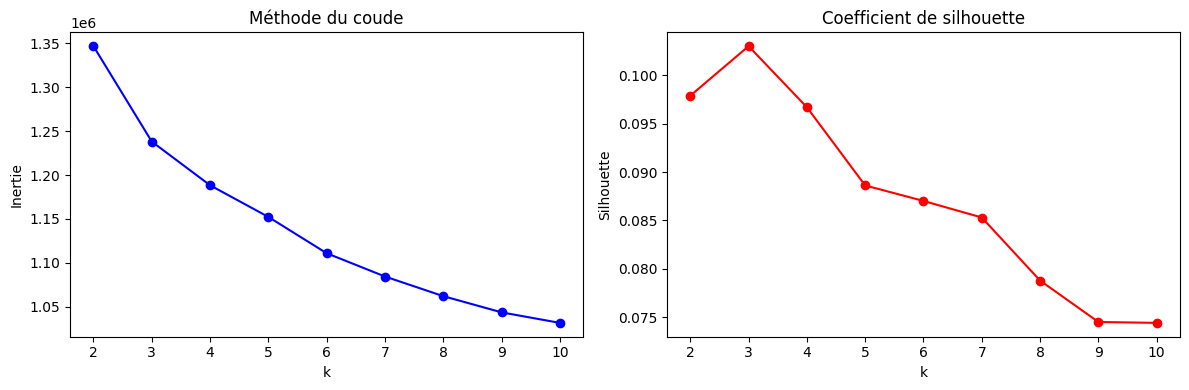

Meilleur k : 3


In [2]:
inertias, silhouettes = [], []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sc)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sc[::10], labels[::10]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(2,11), inertias, 'bo-')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertie')
ax1.set_title('Méthode du coude')
ax2.plot(range(2,11), silhouettes, 'ro-')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette')
ax2.set_title('Coefficient de silhouette')
plt.tight_layout()
plt.savefig('../figures/kmeans_selection_k.png', dpi=150)
plt.show()
print(f'Meilleur k : {np.argmax(silhouettes)+2}')

## 2. K-Means k=3

In [3]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = km.fit_predict(X_sc)
df['cluster_km'] = labels_km
print(f'Silhouette: {silhouette_score(X_sc[::10], labels_km[::10]):.4f}')
print(f'Davies-Bouldin: {davies_bouldin_score(X_sc[::10], labels_km[::10]):.4f}')
print('\nProfils moyens par cluster:')
df.groupby('cluster_km')[['age','bmi','daily_steps','sleep_hours','cholesterol','systolic_bp','smoker']].mean().round(2)

Silhouette: 0.1030
Davies-Bouldin: 2.6551

Profils moyens par cluster:


,age,bmi,daily_steps,sleep_hours,cholesterol,systolic_bp,smoker
cluster_km,,,,,,,
0,48.61,35.02,10505.74,6.50,224.43,142.35,0.20
1,48.45,29.07,10476.07,6.48,224.35,114.54,0.21
2,48.51,24.03,10461.11,6.50,224.17,142.16,0.20


## 3. Visualisation PCA 2D

Variance expliquée: PC1=12.9%, PC2=11.4%


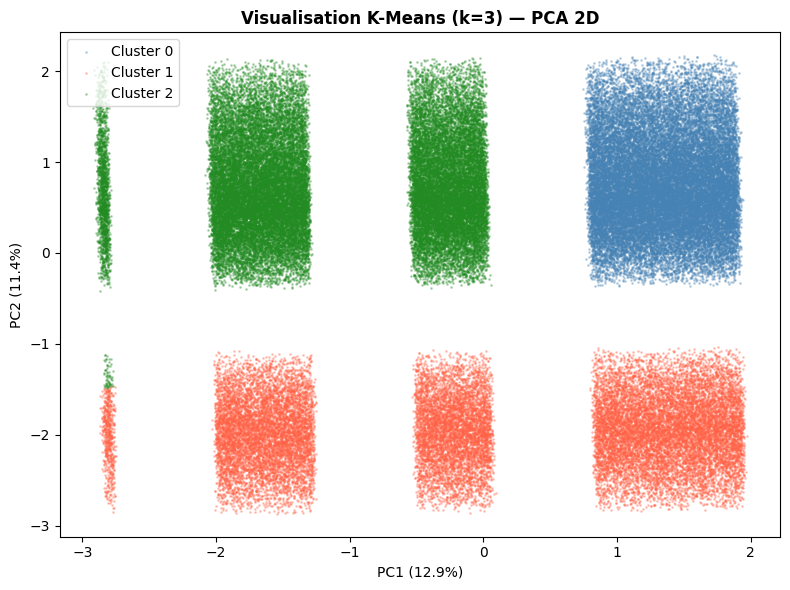

In [4]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sc)
print(f'Variance expliquée: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%')
fig, ax = plt.subplots(figsize=(8,6))
colors = ['steelblue','tomato','forestgreen']
for c in range(3):
    mask = labels_km == c
    ax.scatter(X_pca[mask,0], X_pca[mask,1], c=colors[c], alpha=0.3, s=1, label=f'Cluster {c}')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Visualisation K-Means (k=3) — PCA 2D', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/kmeans_pca.png', dpi=150)
plt.show()

## 4. CAH (Ward, k=3, n=5000)

In [5]:
np.random.seed(42)
idx = np.random.choice(len(X_sc), 5000, replace=False)
X_cah = X_sc[idx]
cah = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_cah = cah.fit_predict(X_cah)
print(f'CAH Silhouette: {silhouette_score(X_cah[::5], labels_cah[::5]):.4f}')
df_cah = df.iloc[idx].copy()
df_cah['cluster_cah'] = labels_cah
print('\nProfils CAH:')
df_cah.groupby('cluster_cah')[['bmi','systolic_bp','smoker','alcohol']].mean().round(3)

CAH Silhouette: 0.1047

Profils CAH:


,bmi,systolic_bp,smoker,alcohol
cluster_cah,,,,
0,29.079,142.078,0.015,0.300
1,29.045,115.064,0.184,0.297
2,28.656,141.653,0.995,0.274
